In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 4 — Nonlinear least squares: fit the curve, not a transform of it

Log-linear regression (lesson 03) works only because the one-compartment
IV model happens to become a straight line under a log. Nothing else in
PK does. The general method is to write the model as a function, hand it
to an optimiser, and let it search for the parameters that minimise the
squared residuals.

We use scipy.optimize.curve_fit. Everything from here on -- oral models,
two compartments, PBPK -- uses the same machinery.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import plotting as P
from tk import load, iv_1comp, half_life, clearance

P.setup()

mk = load("PFOA_Male_primate")
one = mk[(mk.animal_id == 2054) & (mk.conc_mgL > 0)].sort_values("time_d")
t, C, DOSE = one.time_d.values, one.conc_mgL.values, 10.0

## A. The fit, on the log scale

In [3]:
def model_log(t, ln_Vd, ln_k):
    """Predict ln C. Fitting the LOG of the parameters keeps them
    positive without constraints, and fitting the LOG of the prediction
    is what makes the residuals multiplicative (lesson 03, trap 2)."""
    return np.log(iv_1comp(t, DOSE, np.exp(ln_Vd), np.exp(ln_k)))


p0 = [np.log(0.2), np.log(0.07)]
popt, pcov = curve_fit(model_log, t, np.log(C), p0=p0)
Vd, k = np.exp(popt)
# curve_fit returns the covariance of the LOG parameters; on the log
# scale a standard error is (approximately) a relative standard error.
se_ln = np.sqrt(np.diag(pcov))

print("A. One-compartment IV fit by nonlinear least squares\n")
print(f"   Vd        = {Vd:8.4f} L/kg    (x/ {np.exp(1.96*se_ln[0]):.2f} 95% CI)")
print(f"   k         = {k:8.4f} 1/day   (x/ {np.exp(1.96*se_ln[1]):.2f} 95% CI)")
print(f"   half-life = {half_life(k):8.2f} days")
print(f"   clearance = {clearance(k, Vd):8.5f} L/kg/day")

A. One-compartment IV fit by nonlinear least squares

   Vd        =   0.1873 L/kg    (x/ 1.42 95% CI)
   k         =   0.0807 1/day   (x/ 1.16 95% CI)
   half-life =     8.59 days
   clearance =  0.01512 L/kg/day


Log-linear regression on the same points (lesson 03) gave exactly the
same numbers: t1/2 8.59 d, Vd 0.187 L/kg. That is the point -- for
this one model the two methods minimise the same objective, so they
must agree, and matching them is how you check the harder machinery
before you trust it on models where no closed form exists.

What NLS adds is a covariance matrix, and the ability to fit any
model you can write down.

## B. Look at the residuals. Always.

In [4]:
pred = iv_1comp(t, DOSE, Vd, k)
res = np.log(C / pred)
print(f"   {'t (d)':>8s} {'obs':>9s} {'pred':>9s} {'ln(obs/pred)':>13s}")
for ti, ci, pi, ri in zip(t, C, pred, res):
    bar = "#" * int(abs(ri) * 20)
    side = " " * 12 if ri < 0 else ""
    print(f"   {ti:8.3f} {ci:9.3f} {pi:9.3f} {ri:13.3f}  {side}{bar}")

runs = np.sum(np.diff(np.sign(res)) != 0) + 1
print(f"\n   {runs} runs of the same sign in {len(res)} residuals.")

      t (d)       obs      pred  ln(obs/pred)
      0.021    96.660    53.295         0.595  ###########
      0.083    91.630    53.027         0.547  ##########
      0.167    89.160    52.671         0.526  ##########
      0.333    60.860    51.968         0.158  ###
      1.000    50.930    49.246         0.034  
      2.000    48.530    45.428         0.066  #
      4.000    42.940    38.657         0.105  ##
      7.000    27.910    30.345        -0.084              #
     11.000    19.320    21.974        -0.129              ##
     14.000    11.220    17.249        -0.430              ########
     21.000     3.990     9.805        -0.899              #################
     28.000     1.860     5.574        -1.097              #####################
     57.000     0.470     0.537        -0.133              ##
     87.000     0.100     0.048         0.740  ##############

   3 runs of the same sign in 14 residuals.


A good fit scatters residuals randomly around zero. These do not:
strongly positive for the first few days, drifting down through zero,
sharply negative around days 14-28, then positive again at the very
end. Only three sign changes in fourteen points -- neighbouring
residuals are almost perfectly predictable from each other. That
systematic pattern is the model being wrong, not the data being noisy.
No amount of better optimisation fixes it -- you need a better model.

This is the single most useful habit in modelling: plot the residuals
against time, and against the prediction. The pattern tells you what
is missing.

## C. What the uncertainty actually means

In [5]:
# Three quantities derived from pcov, used throughout this section.
corr = pcov[0, 1] / np.sqrt(pcov[0, 0] * pcov[1, 1])     # correlation
se_CL = np.sqrt(pcov[0, 0] + pcov[1, 1] + 2 * pcov[0, 1])  # var(lnVd + lnk)
se_indep = np.sqrt(pcov[0, 0] + pcov[1, 1])   # if they were independent

```text
curve_fit returned two things: popt, the best parameters, and
pcov, a COVARIANCE MATRIX. Most people use the first and ignore the
second. The second is where the interesting information is, so this
section unpacks it from scratch.
```

C1. READING THE COVARIANCE MATRIX


```text
pcov is 2x2 because we fitted two parameters, ln Vd and ln k:

    pcov = [ var(ln Vd)        cov(ln Vd, ln k) ]
           [ cov(ln Vd, ln k)  var(ln k)        ]

The diagonal is how uncertain each parameter is on its own. The
off-diagonal is how they move TOGETHER. That second part is the one
everybody drops, and it is the one that matters here.
```

In [6]:
print("   pcov as curve_fit returned it:\n")
print(f"      [ {pcov[0,0]:+.6f}   {pcov[0,1]:+.6f} ]")
print(f"      [ {pcov[1,0]:+.6f}   {pcov[1,1]:+.6f} ]\n")
print(f"   SE(ln Vd) = sqrt({pcov[0,0]:.6f}) = {se_ln[0]:.4f}")
print(f"   SE(ln k)  = sqrt({pcov[1,1]:.6f}) = {se_ln[1]:.4f}")
print(f"   correlation = cov / (SE * SE) = {corr:+.2f}")

   pcov as curve_fit returned it:

      [ +0.032474   -0.007530 ]
      [ -0.007530   +0.005617 ]

   SE(ln Vd) = sqrt(0.032474) = 0.1802
   SE(ln k)  = sqrt(0.005617) = 0.0749
   correlation = cov / (SE * SE) = -0.56


C2. WHY INTERVALS ARE WRITTEN "x/ 1.42" AND NOT "+/- 0.08"


```text
We fitted the LOGARITHM of each parameter, so the standard errors
are on a log scale. Undoing the log turns a symmetric +/- interval
into a multiplicative one:

    ln Vd = -1.675 +/- 1.96 * 0.180      (95%, log scale)
    Vd    = 0.187 x/ exp(1.96 * 0.180)
          = 0.187 x/ 1.42

"x/ 1.42" means divide and multiply: from 0.187/1.42 = 0.132 up to
0.187*1.42 = 0.266. Asymmetric on the original scale, which is
correct -- a volume cannot be negative, and a plain +/- interval
would eventually claim it could.

Useful shortcut: a log-scale standard error IS roughly a relative
standard error. SE(ln k) = 0.075 means k is known to about +/- 7.5%.
```

In [7]:
print(f"   {'parameter':12s} {'estimate':>9s} {'SE(log)':>8s} {'95% interval':>21s}")
for nm, val, sd in [("Vd (L/kg)", Vd, se_ln[0]), ("k (1/day)", k, se_ln[1])]:
    lo, hi = val / np.exp(1.96 * sd), val * np.exp(1.96 * sd)
    print(f"   {nm:12s} {val:9.4f} {sd:8.4f} {f'{lo:.4f} to {hi:.4f}':>21s}")

# ----------------------------------------------------------------------

   parameter     estimate  SE(log)          95% interval
   Vd (L/kg)       0.1873   0.1802      0.1316 to 0.2667
   k (1/day)       0.0807   0.0749      0.0697 to 0.0935


C3. THE TRADE-OFF, DEMONSTRATED RATHER THAN ASSERTED


```text
That correlation of -0.56 is supposed to mean the two parameters
compensate for each other. Rather than take it on faith, force it:
FIX Vd at a series of deliberately wrong values, refit k on its own,
and watch what happens to the quality of the fit.
```

In [8]:
def refit_k_with_Vd_fixed(Vd_fixed):
    """Best k when Vd is pinned at a value we choose, plus the residual
    sum of squares that results. Statisticians call this profiling."""
    def one_param(tt, ln_k):
        return np.log(iv_1comp(tt, DOSE, Vd_fixed, np.exp(ln_k)))
    p, _ = curve_fit(one_param, t, np.log(C), p0=[np.log(0.06)])
    ssq = float(np.sum((np.log(C) - one_param(t, p[0])) ** 2))
    return float(np.exp(p[0])), ssq


ssq_best = float(np.sum((np.log(C) - model_log(t, *popt)) ** 2))
rows = []
print(f"   {'Vd forced to':>13s} {'best k then':>12s} {'CL = k*Vd':>11s} "
      f"{'sum of squares':>15s} {'vs best':>8s}")
for factor in [0.6, 0.8, 1.0, 1.25, 1.6]:
    Vd_f = Vd * factor
    k_f, ssq = refit_k_with_Vd_fixed(Vd_f)
    rows.append((Vd_f, k_f, k_f * Vd_f, ssq))
    mark = "  <- the actual fit" if factor == 1.0 else ""
    print(f"   {Vd_f:13.4f} {k_f:12.4f} {k_f*Vd_f:11.5f} {ssq:15.4f} "
          f"{ssq/ssq_best:7.2f}x{mark}")

sp = lambda j: max(r[j] for r in rows) / min(r[j] for r in rows)
print(f"""
   Spread across the table: Vd {sp(0):.2f}x, k {sp(1):.2f}x, CL {sp(2):.2f}x,
   sum of squares {sp(3):.2f}x.

   Three things to read off it.

   1. Forcing Vd well away from its best value costs surprisingly
      little. Vd varies {sp(0):.1f}-fold here and the sum of squares rises only
      {sp(3):.1f}-fold. The data genuinely struggle to distinguish these
      cases, which is what the wide Vd interval was telling you.

   2. k moved the OPPOSITE way every time. A lower Vd lifts the whole
      curve, so the optimiser steepens the decay to compensate. That is
      the negative covariance, seen as behaviour rather than as a
      number in a matrix.

   3. The compensation is PARTIAL, not complete. k moves only {sp(1):.2f}x
      while Vd moves {sp(0):.2f}x, so CL still drifts {sp(2):.2f}x across the table.
      If the two parameters cancelled perfectly, the CL column would be
      constant and the correlation would be -1. It is -0.56, so you get
      about half of that benefit: CL ends up x/ 1.35 against Vd's
      x/ 1.42 -- better, but only slightly.

   Point 3 is the one worth carrying. A trade-off between parameters
   means SOME combination of them is better determined than either
   alone, but how much better depends on how close the correlation is
   to -1. Do not assume a derived quantity is well pinned just because
   you spotted a trade-off; compute it, as C4 does next.
""")

# ----------------------------------------------------------------------

    Vd forced to  best k then   CL = k*Vd  sum of squares  vs best
          0.1124       0.0903     0.01014          6.2768    1.67x
          0.1499       0.0849     0.01272          4.2398    1.13x
          0.1873       0.0807     0.01512          3.7594    1.00x  <- the actual fit
          0.2342       0.0765     0.01792          4.2398    1.13x
          0.2997       0.0719     0.02155          5.8905    1.57x

   Spread across the table: Vd 2.67x, k 1.26x, CL 2.12x,
   sum of squares 1.67x.

   Three things to read off it.

   1. Forcing Vd well away from its best value costs surprisingly
      little. Vd varies 2.7-fold here and the sum of squares rises only
      1.7-fold. The data genuinely struggle to distinguish these
      cases, which is what the wide Vd interval was telling you.

   2. k moved the OPPOSITE way every time. A lower Vd lifts the whole
      curve, so the optimiser steepens the decay to compensate. That is
      the negative covariance, seen as behaviour ra

C4. PROPAGATING UNCERTAINTY TO A DERIVED QUANTITY


```text
You rarely care about ln Vd and ln k themselves. You care about
half-life, or clearance. Those are functions of the parameters, so
their uncertainty has to be built out of pcov -- and this is exactly
where the off-diagonal term earns its keep.

For CL = k * Vd, take logs to turn the product into a sum:

    ln CL = ln k + ln Vd

and for any two correlated quantities,

    var(a + b) = var(a) + var(b) + 2 * cov(a, b)
                 \\_________________/   \\___________/
                  what you would use     the correction for
                  if independent         them moving together

Because cov is NEGATIVE here, that correction SUBTRACTS. Errors that
cancel make the product BETTER determined than the two factors
would suggest on their own.
```

In [9]:
var_indep = pcov[0, 0] + pcov[1, 1]
var_true = var_indep + 2 * pcov[0, 1]
print(f"   var(ln Vd) + var(ln k)   = {var_indep:+.6f}    "
      f"-> x/ {np.exp(1.96*np.sqrt(var_indep)):.2f}")
print(f"   2 * cov(ln Vd, ln k)     = {2*pcov[0,1]:+.6f}")
print(f"   ----------------------------------")
print(f"   var(ln CL)               = {var_true:+.6f}    "
      f"-> x/ {np.exp(1.96*np.sqrt(var_true)):.2f}\n")

print(f"   {'quantity':26s} {'95% interval':>14s}")
for nm, sd in [("Vd", se_ln[0]), ("k", se_ln[1]), ("CL = k*Vd", se_CL),
               ("CL if treated as indep", se_indep)]:
    print(f"   {nm:26s} {'x/ ' + format(np.exp(1.96 * sd), '.2f'):>14s}")

print(f"""
   Ignoring the correlation would have you report CL as x/ 1.47 when
   the honest answer is x/ 1.35 -- overstating your uncertainty by
   about a third. Never quote a Vd interval and a k interval as though
   they were two separate facts.

C5. TWO WARNINGS BEFORE YOU TRUST ANY OF THIS

   First: CL is NOT the best-determined quantity here. k is, at
   x/ {np.exp(1.96*se_ln[1]):.2f} against CL's x/ {np.exp(1.96*se_CL):.2f}. The sharpest thing this
   experiment measured is the SLOPE of the decay; Vd is the loosest.
   Look at figures/04_tradeoff.png: the valley of good fits is
   elongated, so one DIRECTION in (Vd, k) space is well determined and
   the perpendicular one is not -- and neither direction lines up with
   an axis, which is precisely why the covariance term is non-zero.

   Second, and far more important: none of this accounts for the
   one-compartment model being WRONG. Every number above is
   conditional on the model being right. Section B showed it is not. A
   tight confidence interval around a wrong model is not reassurance;
   it is a precise answer to the wrong question.
""")

   var(ln Vd) + var(ln k)   = +0.038091    -> x/ 1.47
   2 * cov(ln Vd, ln k)     = -0.015061
   ----------------------------------
   var(ln CL)               = +0.023030    -> x/ 1.35

   quantity                     95% interval
   Vd                                x/ 1.42
   k                                 x/ 1.16
   CL = k*Vd                         x/ 1.35
   CL if treated as indep            x/ 1.47

   Ignoring the correlation would have you report CL as x/ 1.47 when
   the honest answer is x/ 1.35 -- overstating your uncertainty by
   about a third. Never quote a Vd interval and a k interval as though
   they were two separate facts.

C5. TWO WARNINGS BEFORE YOU TRUST ANY OF THIS

   First: CL is NOT the best-determined quantity here. k is, at
   x/ 1.16 against CL's x/ 1.35. The sharpest thing this
   experiment measured is the SLOPE of the decay; Vd is the loosest.
   Look at figures/04_tradeoff.png: the valley of good fits is
   elongated, so one DIRECTION in (Vd, k) spac

## D. A check that needs no model at all

D1. WHAT AUC IS


```text
AUC is the Area Under the concentration-time Curve -- the measured
concentration integrated over time:

    AUC = integral of C(t) dt, from t=0 to infinity

Units are (mg/L) x day = mg*day/L. It is neither a concentration nor
a time: it is TOTAL EXPOSURE, "how much, for how long", in a single
number. Two animals with the same peak but different decay rates
have different AUCs, and the slower one was more exposed.

You get it from data with the TRAPEZOID RULE: take each pair of
consecutive measurements as the two corners of a trapezoid, compute
its area as (average height) x (width), and add them up. No model,
no fitting -- just arithmetic on the measurements.

    strip area = (C[i] + C[i+1]) / 2  x  (t[i+1] - t[i])
```

In [10]:
auc_steps = 0.5 * (C[1:] + C[:-1]) * np.diff(t)
auc_obs = float(auc_steps.sum())
print(f"   {'from':>7s} {'to':>7s} {'C_from':>9s} {'C_to':>8s} "
      f"{'width':>7s} {'strip area':>11s} {'% of total':>11s}")
for i in [0, 1, 5, 8, 10, 11, 12]:
    print(f"   {t[i]:7.3f} {t[i+1]:7.1f} {C[i]:9.2f} {C[i+1]:8.2f} "
          f"{t[i+1]-t[i]:7.2f} {auc_steps[i]:11.2f} "
          f"{100*auc_steps[i]/auc_obs:10.1f}%")
print(f"   {'(7 of 13 strips shown)':>43s}  {'-'*11}")
print(f"   {'total of all 13':>43s}  {auc_obs:11.2f}")

      from      to    C_from     C_to   width  strip area  % of total
     0.021     0.1     96.66    91.63    0.06        5.88        1.0%
     0.083     0.2     91.63    89.16    0.08        7.53        1.3%
     2.000     4.0     48.53    42.94    2.00       91.47       16.1%
    11.000    14.0     19.32    11.22    3.00       45.81        8.1%
    21.000    28.0      3.99     1.86    7.00       20.48        3.6%
    28.000    57.0      1.86     0.47   29.00       33.79        6.0%
    57.000    87.0      0.47     0.10   30.00        8.55        1.5%
                        (7 of 13 strips shown)  -----------
                               total of all 13       566.97


```text
Notice how uneven the strips are. The widest ones -- late in the
study, where sampling is sparse -- carry a large share of the area
even though the concentrations there are small. AUC is driven by
DURATION at least as much as by height, which is the opposite of
most people's intuition and the reason a study that stops early
mismeasures it.
```

D2. WHY dose/AUC IS THE CLEARANCE -- the derivation


```text
This is the one piece of algebra worth doing by hand, because it
explains why anyone bothers computing an area in the first place.

Clearance is DEFINED as the constant linking the rate at which
chemical leaves the body to the concentration driving it:

    rate of elimination = CL * C(t)                          (1)

The amount A in the body falls at exactly that rate:

    dA/dt = -CL * C(t)                                       (2)

Integrate both sides over all time, 0 to infinity:

    A(inf) - A(0) = -CL * integral C(t) dt                   (3)

Now substitute what you know. Everything is eliminated eventually,
so A(inf) = 0. For an IV bolus the entire dose is in the body at
t = 0, so A(0) = dose. And that integral is, by definition, AUC:

    0 - dose = -CL * AUC

         CL = dose / AUC                                     (4)

Now look hard at what that derivation never used. It never mentions
compartments. It never mentions a volume. It never assumes any
particular shape for C(t). All it needs is that elimination is
first order (equation 1) and that the dose went in intravenously.

One compartment, two, or twenty -- same answer. THAT is what
"NONCOMPARTMENTAL analysis" means: the result does not depend on a
structural model you might have chosen wrongly.
```

In [11]:
auc_tail = float(C[-1] / k)
auc_total = auc_obs + auc_tail
print(f"""D3. THE TAIL, WHICH IS WHERE IT CAN GO WRONG

   Equation (3) integrates to INFINITY. Your study stopped at day
   {t[-1]:.0f}. The area beyond the last sample has to be estimated, and it
   is only here that a model assumption sneaks back in: assume the
   curve keeps decaying log-linearly at rate k, and the missing area
   is C_last / k.
""")
print(f"   area measured by trapezoids   = {auc_obs:9.2f} mg*day/L  "
      f"({100*auc_obs/auc_total:5.1f}%)")
print(f"   area extrapolated (C_last/k)  = {auc_tail:9.2f}            "
      f"({100*auc_tail/auc_total:5.1f}%)")
print(f"   {'':31s}   {'-'*9}")
print(f"   AUC total                     = {auc_total:9.2f}\n")
print(f"   CL = dose / AUC               = {DOSE/auc_total:9.5f} L/kg/day")
print(f"   CL from the fitted model      = {clearance(k, Vd):9.5f} L/kg/day")
print(f"   difference                    = "
      f"{100*abs(DOSE/auc_total/clearance(k, Vd)-1):8.1f}%")

gap = 100 * abs(DOSE / auc_total / clearance(k, Vd) - 1)
print(f"""
   Rule of thumb: if more than 20% of your AUC is extrapolated, the
   AUC is not trustworthy. Here it is well under 1%, because the study
   ran 87 days on a ~10-day half-life -- about 8 half-lives, by which
   point there is almost nothing left to miss. So the AUC is solid,
   and any disagreement is the MODEL's fault, not the area's.

D4. WHAT THIS CHECK IS FOR -- AND IT JUST FIRED

   You now have two clearances computed in completely different ways:
   one from the fitted one-compartment model, one from the raw area
   with no model at all. Comparing them tests the MODEL, not the data.

   They disagree by {gap:.0f}%.

   That is the check doing its job. Section B already showed this
   model's shape is wrong -- the residuals sweep instead of scattering
   -- and here is the consequence in a number you might actually
   report. Forcing a single exponential through a curve that bends
   makes the fitted line sit too high through the long tail, which
   inflates the model's implied area and therefore DEFLATES its
   clearance. NCA, which just adds up the measurements, is not fooled.

   Which of the two should you believe? The NCA one, {DOSE/auc_total:.5f}. It
   rests on an assumption you have verified (first-order elimination,
   99.8% of the area measured rather than extrapolated) instead of one
   you have falsified (one compartment).

   You can confirm this diagnosis rather than take it on trust. Lesson
   09 fits the SAME animal with a two-compartment model and computes
   both clearances again -- and there they agree to five decimal
   places. Same data, same NCA calculation; the only thing that
   changed was the structural model. A {gap:.0f}% gap here, none there, is as
   direct a demonstration as you will get that the gap measures model
   error.

   The habit worth forming: whenever you can compute a quantity two
   ways, do it. A model that fits badly can still get some things
   right and other things wrong, and only a model-free cross-check
   tells you which is which.
""")

D3. THE TAIL, WHICH IS WHERE IT CAN GO WRONG

   Equation (3) integrates to INFINITY. Your study stopped at day
   87. The area beyond the last sample has to be estimated, and it
   is only here that a model assumption sneaks back in: assume the
   curve keeps decaying log-linearly at rate k, and the missing area
   is C_last / k.

   area measured by trapezoids   =    566.97 mg*day/L  ( 99.8%)
   area extrapolated (C_last/k)  =      1.24            (  0.2%)
                                     ---------
   AUC total                     =    568.21

   CL = dose / AUC               =   0.01760 L/kg/day
   CL from the fitted model      =   0.01512 L/kg/day
   difference                    =     16.4%

   Rule of thumb: if more than 20% of your AUC is extrapolated, the
   AUC is not trustworthy. Here it is well under 1%, because the study
   ran 87 days on a ~10-day half-life -- about 8 half-lives, by which
   point there is almost nothing left to miss. So the AUC is solid,
   and any di

## E. Figures

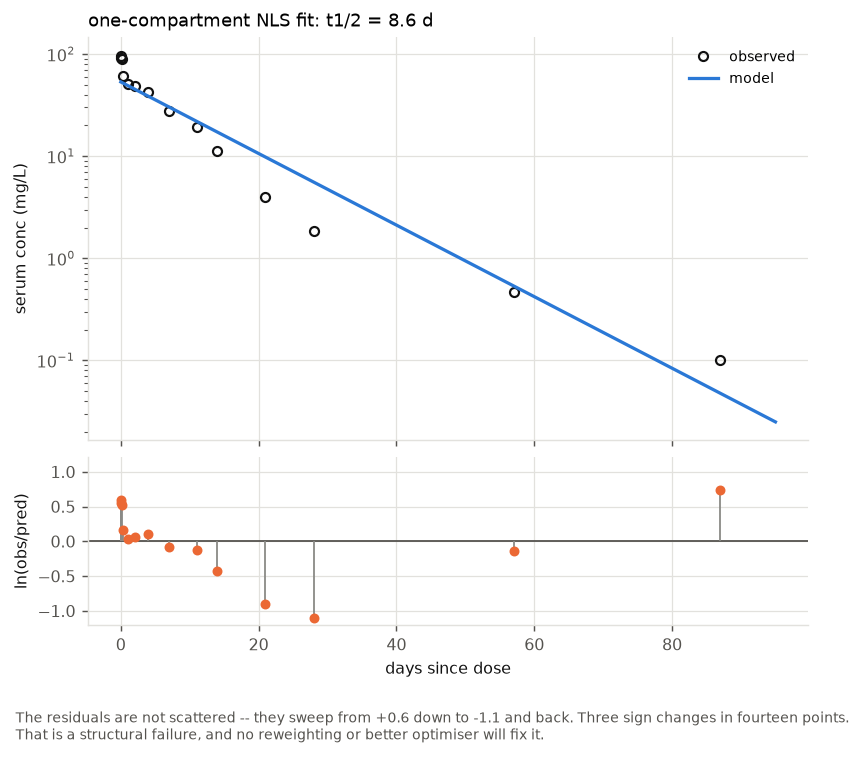

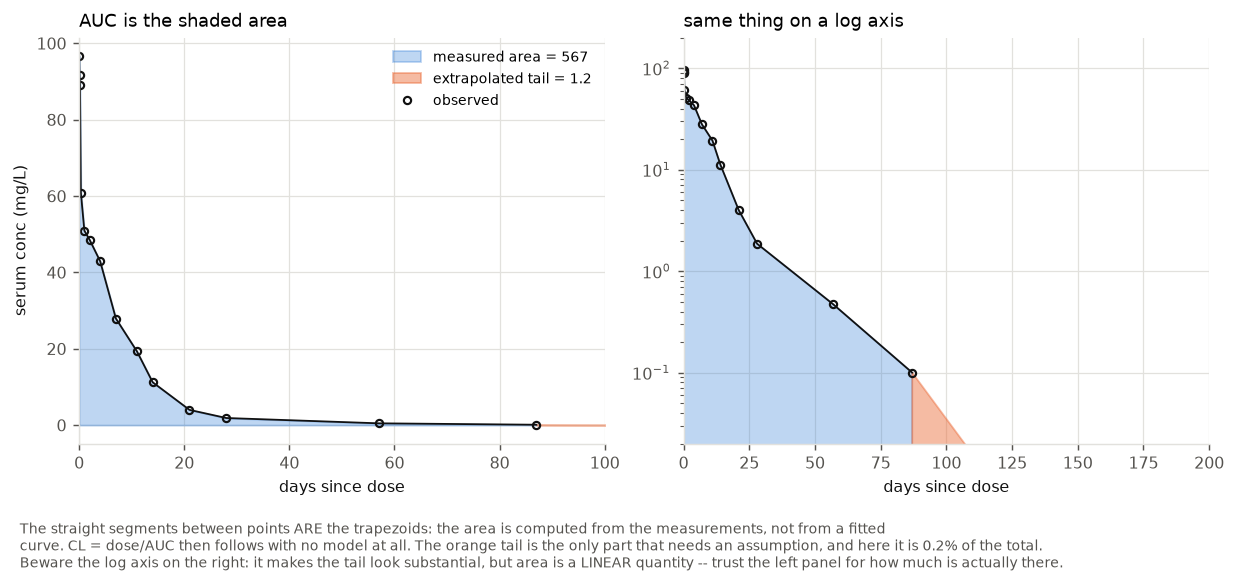

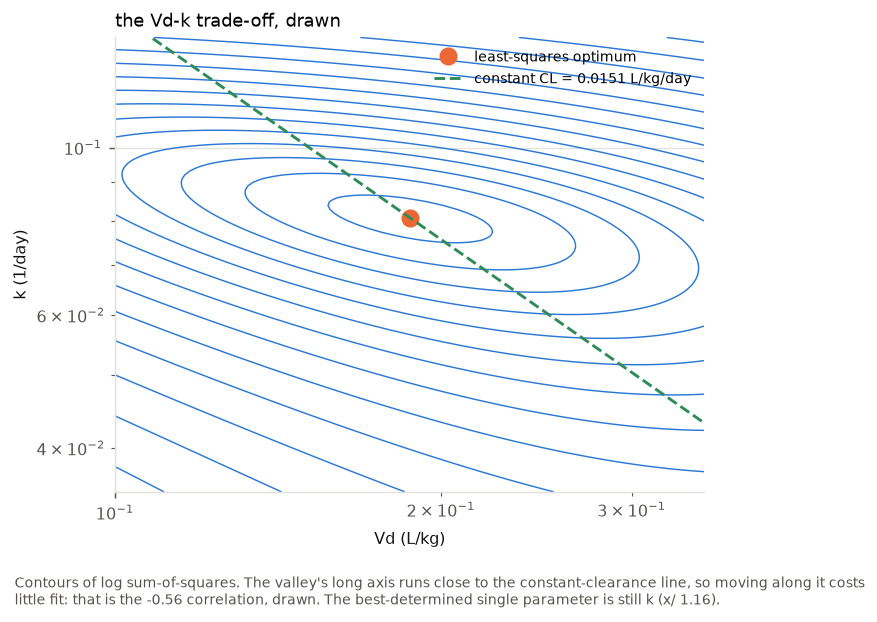

'/home/user/chiu__2022_rerun/tk_learning/figures/04_tradeoff.png'

In [12]:
# E1 -- the standard two-panel diagnostic. Look at the bottom panel first.
grid = np.linspace(0.01, 95, 400)
P.fit_and_residuals(
    t, C, grid, iv_1comp(grid, DOSE, Vd, k), iv_1comp(t, DOSE, Vd, k),
    title=f"one-compartment NLS fit: t1/2 = {half_life(k):.1f} d",
    name="04_fit_residuals.png",
    note="The residuals are not scattered -- they sweep from +0.6 down to "
         "-1.1 and back. Three sign changes in fourteen points.\n"
         "That is a structural failure, and no reweighting or better "
         "optimiser will fix it.")

# E2 -- what AUC actually is: the trapezoids, and the tail.
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.8), constrained_layout=True)
tail_t = np.linspace(t[-1], 200, 300)
for ax, logy in [(a, False), (b, True)]:
    ax.fill_between(t, C, color=P.BLUE, alpha=0.30, step=None,
                    label=f"measured area = {auc_obs:.0f}")
    ax.fill_between(tail_t, C[-1] * np.exp(-k * (tail_t - t[-1])),
                    color=P.ORANGE, alpha=0.45,
                    label=f"extrapolated tail = {auc_tail:.1f}")
    ax.plot(t, C, "-", color=P.INK, lw=1.0)
    P.data_points(ax, t, C, label="observed", ms=4)
    ax.set_xlabel("days since dose")
    if logy:
        ax.set(yscale="log", ylim=(0.02, 200), xlim=(0, 200))
        ax.set_title("same thing on a log axis")
    else:
        ax.set(ylabel="serum conc (mg/L)", xlim=(0, 100))
        ax.set_title("AUC is the shaded area")
a.legend(fontsize=8)
P.save(fig, "04_auc.png",
       "The straight segments between points ARE the trapezoids: the "
       "area is computed from the measurements, not from a fitted\n"
       "curve. CL = dose/AUC then follows with no model at all. The "
       "orange tail is the only part that needs an assumption, and "
       f"here it is {100*auc_tail/auc_total:.1f}% of the total.\n"
       "Beware the log axis on the right: it makes the tail look "
       "substantial, but area is a LINEAR quantity -- trust the left "
       "panel for how much is actually there.")

# E3 -- the parameter trade-off, as the likelihood surface itself.
vv = np.linspace(np.log(0.10), np.log(0.35), 120)
kk = np.linspace(np.log(0.035), np.log(0.14), 120)
V, K = np.meshgrid(vv, kk)
SSQ = np.array([[np.sum((np.log(C) - model_log(t, v, kx)) ** 2)
                 for v in vv] for kx in kk])
fig, ax = plt.subplots(figsize=(5.4, 4.2), constrained_layout=True)
cs = ax.contour(np.exp(V), np.exp(K), np.log(SSQ), levels=14,
                colors=P.BLUE, linewidths=0.8)
ax.plot(Vd, k, "o", color=P.ORANGE, ms=9, label="least-squares optimum")
# the line of constant clearance through the optimum
vline = np.exp(vv)
ax.plot(vline, clearance(k, Vd) / vline, "--", color=P.GREEN, lw=1.6,
        label=f"constant CL = {clearance(k, Vd):.4f} L/kg/day")
ax.set(xlabel="Vd (L/kg)", ylabel="k (1/day)", xscale="log", yscale="log",
       ylim=(0.035, 0.14))
ax.set_title("the Vd-k trade-off, drawn")
ax.legend(loc="upper right")
P.save(fig, "04_tradeoff.png",
       "Contours of log sum-of-squares. The valley's long axis runs "
       "close to the constant-clearance line, so moving along it costs\n"
       "little fit: that is the -0.56 correlation, drawn. The "
       "best-determined single parameter is still k (x/ 1.16).")

### Questions

1. Section D3: what fraction of the AUC was extrapolated, and why is that fraction so small here? What study design would make it big?
1. Why does CL = dose/AUC hold for a two-compartment model too? (Hint: integrate dA/dt = -CL*C over all time.)
1. Section C4: CL is better determined than Vd but worse than k. Work out why from var(lnVd + lnk) = var(lnVd) + var(lnk) + 2cov -- which term has to dominate for CL to beat BOTH?
1. Section C3 forced Vd to wrong values and refitted k. If the correlation were -1.0 instead of -0.56, what would the CL column of that table look like, and what would CL's interval be?
1. Section D4: NCA says CL = 0.0176, the one-compartment fit says 0.0151. Explain the DIRECTION of that error -- why does a too-simple model under-estimate clearance here rather than over-estimate it? (Look at figures/04_fit_residuals.png: where does the fitted line sit relative to the data late on?)
1. If you had only the first 7 days of this curve, which of Vd, k and CL would still be well estimated?

### Exercises

1. Fit the other two monkeys and compare. Do their intervals overlap?
1. Refit using only t >= 7 days. The residual pattern should improve and the half-life should lengthen. By how much? You have now rediscovered, by a different route, the terminal-phase judgement call from lesson 03.
1. Change model_log to fit on the linear scale instead (return the concentration, pass C not log C). Which points now dominate the fit, and what happens to the half-life?
1. Rerun section C3 with a much wider range of forced Vd values (0.2x to 5x). At what point does the sum of squares rise enough that you WOULD notice? That boundary is, roughly, what the confidence interval is reporting.
1. Recompute the AUC dropping the last three observations, as though the study had stopped at day 21. How large is the extrapolated fraction now, and how much does CL move? You have just simulated the commonest flaw in the published PK literature.